# 07 - Model comparison
Owner: Engineer 4

Pulls together all five models (baseline + LSTM + CNN + TCN + Transformer) on the same split/preprocessing/metric. Just reads what 02-06 already produced - doesn't train anything.

Result: Transformer wins (0.9866), then CNN (0.9851), baseline (0.9747), TCN (0.8838), LSTM (0.8754). All 5 models agree on 7,832/7,931 validation tweets.

## 1. Setup
Same as earlier notebooks.

In [1]:
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/Manzi453/Formative_2-Group_19.git"
BRANCH = "feature/baseline-tfidf"  # change to main once merged

if "google.colab" in sys.modules:
    if not Path("Formative_2-Group_19").exists():
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
    os.chdir("Formative_2-Group_19")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    if Path.cwd().name == "notebooks":
        os.chdir("..")

sys.path.insert(0, str(Path.cwd()))
print("Working directory:", Path.cwd())

Working directory: /Users/manziivan453icloud.com/Downloads/Projects/Ivan /Formative_2-Group_19


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils import set_seed, SEED, RESULTS_DIR
from src.evaluation import confusion
from src.plotting import save_fig

set_seed()
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50, "display.width", 140)

METRICS = RESULTS_DIR / "metrics"
PREDICTIONS = RESULTS_DIR / "predictions"

MODELS = {
    "TF-IDF + LogReg": {"experiment_id": "baseline_tfidf_logreg_v1",
                         "per_class": "baseline_per_class_report.csv",
                         "predictions": "baseline_val_predictions.csv"},
    "LSTM": {"experiment_id": "lstm_final_v1",
             "per_class": "lstm_per_class_report.csv",
             "predictions": "lstm_val_predictions.csv"},
    "CNN": {"experiment_id": "cnn_final_v1",
            "per_class": "cnn_per_class_report.csv",
            "predictions": "cnn_val_predictions.csv"},
    "TCN": {"experiment_id": "tcn_final_v1",
            "per_class": "tcn_per_class_report.csv",
            "predictions": "tcn_val_predictions.csv"},
    "Transformer": {"experiment_id": "transformer_final_v1",
                     "per_class": "transformer_per_class_report.csv",
                     "predictions": "transformer_val_predictions.csv"},
}
print("seed =", SEED, "| models compared:", list(MODELS))

seed = 42 | models compared: ['TF-IDF + LogReg', 'LSTM', 'CNN', 'TCN', 'Transformer']


## 2. Master results table
One row per model, straight from `experiments.csv`.

In [3]:
exp_log = pd.read_csv(METRICS / "experiments.csv")
exp_log = exp_log.drop_duplicates(subset="experiment_id", keep="last")  # re-running a notebook appends, not overwrites
ids = [cfg["experiment_id"] for cfg in MODELS.values()]
missing = [i for i in ids if i not in set(exp_log["experiment_id"])]
if missing:
    print(f"WARNING: missing experiment log rows for {missing} - run the corresponding notebook(s) first.")

master = exp_log[exp_log["experiment_id"].isin(ids)].copy()
numeric_cols = ["validation_accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]
master[numeric_cols] = master[numeric_cols].apply(pd.to_numeric, errors="coerce")  # logged as strings; other rows mix in "NOT YET MEASURED"
id_to_name = {cfg["experiment_id"]: name for name, cfg in MODELS.items()}
master["model_name"] = master["experiment_id"].map(id_to_name)
display_cols = ["model_name", "model", "preprocessing", "sequence_length", "embedding", "train_time",
                 "validation_accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]
master = master[display_cols].sort_values("macro_f1", ascending=False).reset_index(drop=True)
master.to_csv(METRICS / "model_comparison.csv", index=False)
master

,model_name,model,preprocessing,sequence_length,embedding,train_time,validation_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Transformer,transformer,A_minimal,64,learned_100d,589.9s,0.9991,0.9785,0.9950,0.9866,0.9991
1,CNN,cnn,A_minimal,64,learned_100d,84.5s,0.9992,0.9983,0.9737,0.9851,0.9992
2,TF-IDF + LogReg,tfidf_logreg,A_minimal,n/a (bag-of-ngrams),NaN,2.7s,0.9958,0.9632,0.9882,0.9747,0.9959
3,TCN,tcn,A_minimal,64,learned_100d,341.5s,0.9951,0.8931,0.8754,0.8838,0.9950
4,LSTM,lstm,A_minimal,64,learned_128d,89.4s,0.9956,0.8716,0.8800,0.8754,0.9956


## 3. Macro-F1 / accuracy comparison
Macro-F1 is the metric that matters here given the class imbalance.

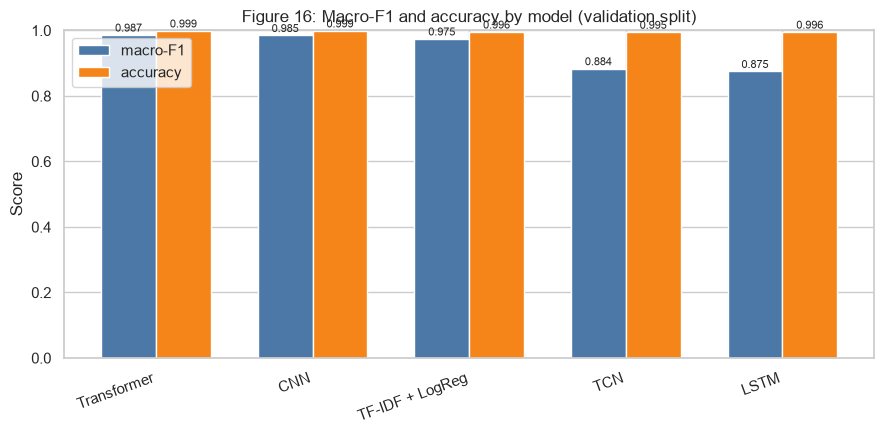

In [4]:
plot_df = master.set_index("model_name")[["macro_f1", "validation_accuracy"]]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(plot_df))
width = 0.35
ax.bar(x - width / 2, plot_df["macro_f1"], width, label="macro-F1", color="#4C78A8")
ax.bar(x + width / 2, plot_df["validation_accuracy"], width, label="accuracy", color="#F58518")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Figure 16: Macro-F1 and accuracy by model (validation split)")
ax.legend()
for i, (f1, acc) in enumerate(zip(plot_df["macro_f1"], plot_df["validation_accuracy"])):
    ax.text(i - width / 2, f1 + 0.01, f"{f1:.3f}", ha="center", fontsize=8)
    ax.text(i + width / 2, acc + 0.01, f"{acc:.3f}", ha="center", fontsize=8)
fig.tight_layout()
save_fig(fig, "fig16_model_comparison_bars")
plt.show()

## 4. Per-class performance comparison
F1 per class per model - the smallest classes are where architecture differences tend to show.

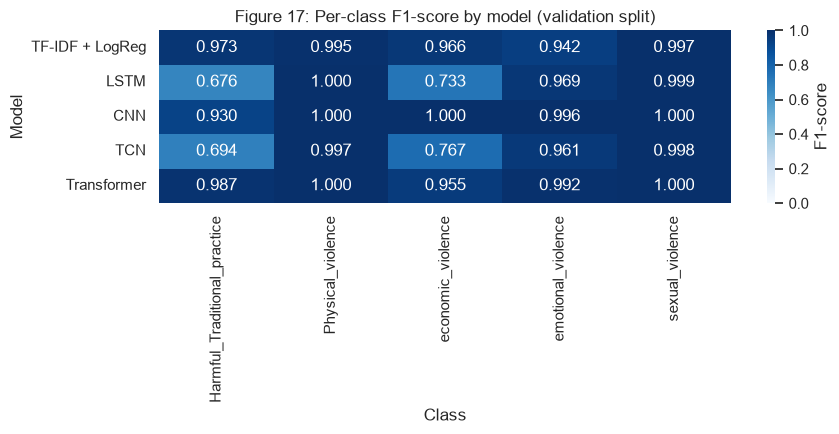

In [5]:
per_class_f1 = {}
for name, cfg in MODELS.items():
    path = METRICS / cfg["per_class"]
    if not path.exists():
        continue
    rep = pd.read_csv(path, index_col=0)
    rep = rep.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")
    per_class_f1[name] = rep["f1-score"]

per_class_f1 = pd.DataFrame(per_class_f1)
per_class_f1.to_csv(METRICS / "model_comparison_per_class_f1.csv")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(per_class_f1.T, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, ax=ax,
            cbar_kws={"label": "F1-score"})
ax.set_xlabel("Class")
ax.set_ylabel("Model")
ax.set_title("Figure 17: Per-class F1-score by model (validation split)")
fig.tight_layout()
save_fig(fig, "fig17_per_class_f1_heatmap")
plt.show()

## 5. Confusion matrix comparison

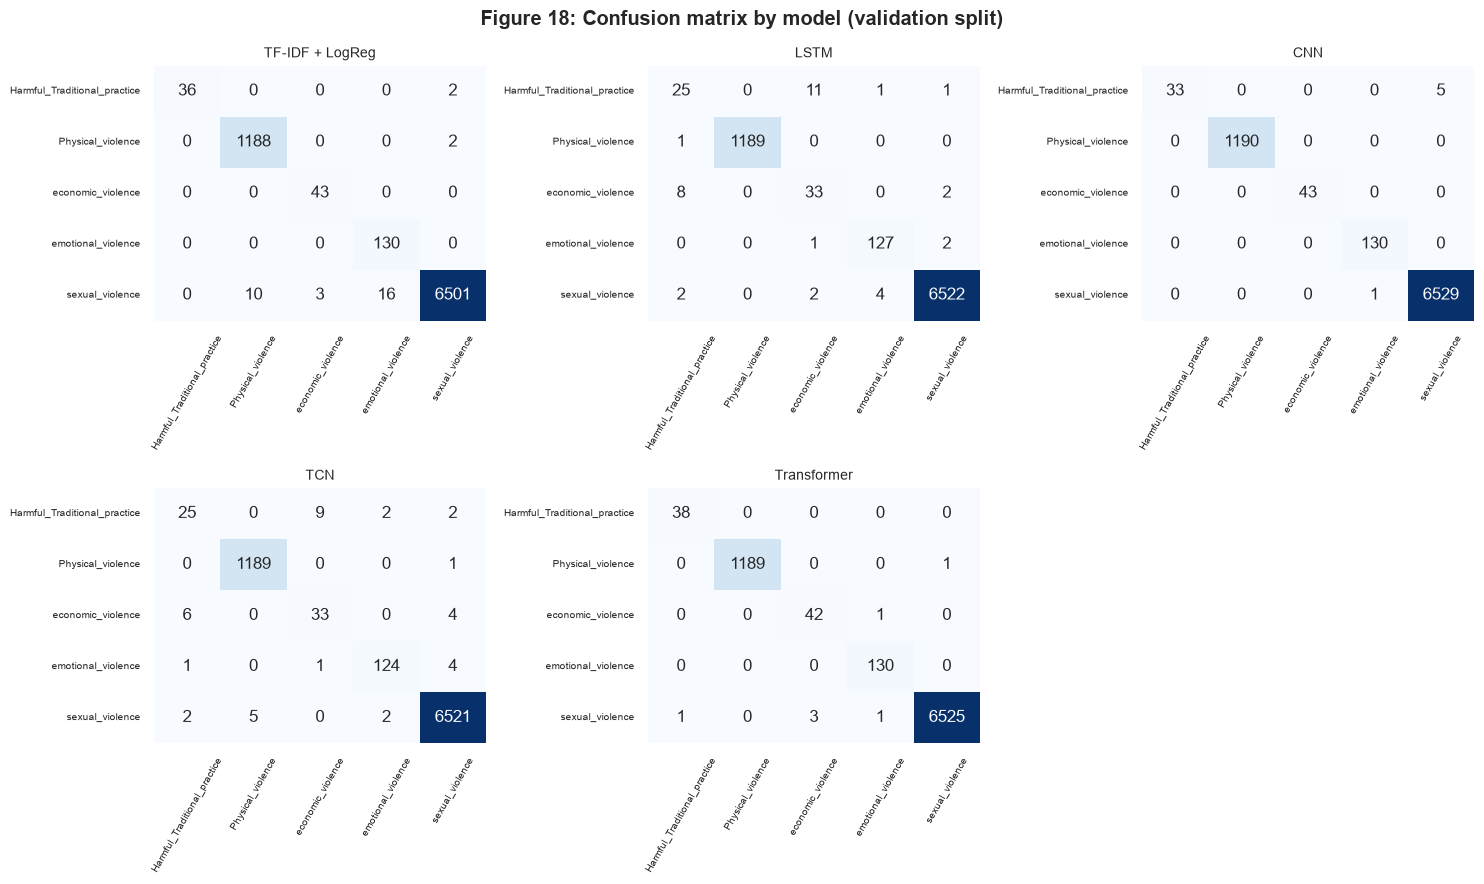

In [6]:
CLASS_ORDER = list(per_class_f1.index)
predictions = {}
for name, cfg in MODELS.items():
    path = PREDICTIONS / cfg["predictions"]
    if path.exists():
        predictions[name] = pd.read_csv(path)

n_models = len(predictions)
n_cols = 3
n_rows = -(-n_models // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = np.atleast_1d(axes).ravel()
for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion(preds["true_label"], preds["predicted_label"], labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis="x", rotation=60, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)
for ax in axes[len(predictions):]:
    ax.axis("off")
fig.suptitle("Figure 18: Confusion matrix by model (validation split)", fontweight="bold")
fig.tight_layout()
save_fig(fig, "fig18_confusion_matrix_grid")
plt.show()

## 6. Error overlap - where do models agree and disagree?
How many models get each tweet right. No tweet text shown, just IDs/labels.

In [7]:
merged = None
for name, preds in predictions.items():
    correct = preds.assign(**{f"{name}_correct": preds["true_label"] == preds["predicted_label"]})
    correct = correct[["Tweet_ID", "true_label", f"{name}_correct"]]
    merged = correct if merged is None else merged.merge(correct, on=["Tweet_ID", "true_label"])

correct_cols = [f"{name}_correct" for name in predictions]
merged["n_models_correct"] = merged[correct_cols].sum(axis=1)
merged.to_csv(METRICS / "model_comparison_error_overlap.csv", index=False)

agreement_dist = merged["n_models_correct"].value_counts().sort_index()
print("Validation tweets by number of models that classified them correctly (of", len(predictions), "):")
display(agreement_dist.rename("n_tweets").to_frame())

all_wrong = int((merged["n_models_correct"] == 0).sum())
all_right = int((merged["n_models_correct"] == len(predictions)).sum())
baseline_col = "TF-IDF + LogReg_correct"
other_cols = [c for c in correct_cols if c != baseline_col]
baseline_only_wrong = (
    int((~merged[baseline_col] & merged[other_cols].all(axis=1)).sum())
    if baseline_col in merged.columns and other_cols else None
)
print(f"All {len(predictions)} models wrong: {all_wrong} tweets | all correct: {all_right} tweets")
if baseline_only_wrong is not None:
    print(f"Every sequential model right, TF-IDF baseline wrong: {baseline_only_wrong} tweets "
          "(evidence sequence modelling adds signal the baseline misses).")

Validation tweets by number of models that classified them correctly (of 5 ):


,n_tweets
n_models_correct,
2,5
3,11
4,83
5,7832


All 5 models wrong: 0 tweets | all correct: 7832 tweets
Every sequential model right, TF-IDF baseline wrong: 30 tweets (evidence sequence modelling adds signal the baseline misses).


## 7. Hypotheses and discussion
Ties the numbers back to the project's research question.

In [8]:
best_model = master.iloc[0]["model_name"]
best_f1 = master.iloc[0]["macro_f1"]
baseline_row = master.loc[master["model_name"] == "TF-IDF + LogReg"].iloc[0]
sequential_rows = master[master["model_name"] != "TF-IDF + LogReg"]
best_sequential = sequential_rows.iloc[0] if len(sequential_rows) else None

findings = {
    "best overall model": f"{best_model} (macro-F1={best_f1:.4f})",
    "non-sequential baseline (TF-IDF + LogReg)": f"macro-F1={baseline_row['macro_f1']:.4f}",
}
if best_sequential is not None:
    findings["best sequential model"] = f"{best_sequential['model_name']} (macro-F1={best_sequential['macro_f1']:.4f})"
    findings["best sequential vs baseline"] = f"{best_sequential['macro_f1'] - baseline_row['macro_f1']:+.4f} macro-F1"
findings["validation tweets all models agree on (correct)"] = f"{all_right} / {len(merged)}"
findings["validation tweets all models get wrong"] = f"{all_wrong} / {len(merged)}"
if baseline_only_wrong is not None:
    findings["tweets only sequential models get right"] = baseline_only_wrong

pd.Series(findings, name="finding").to_frame()

,finding
best overall model,Transformer (macro-F1=0.9866)
non-sequential baseline (TF-IDF + LogReg),macro-F1=0.9747
best sequential model,Transformer (macro-F1=0.9866)
best sequential vs baseline,+0.0119 macro-F1
validation tweets all models agree on (correct),7832 / 7931
validation tweets all models get wrong,0 / 7931
tweets only sequential models get right,30
